In [1]:
%run utilities_general.ipynb 
%run utilities_DIRKs_and_PIRKs.ipynb
load_standard_packages()
change_wordir()
from matplotlib.lines import Line2D

C:\Users\andre\AppData\Local\Temp\ipykernel_32944\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
analysis = "kinetic_analysis"

colors, colours = colourblind_palette("own")

# model = "saadat21"
model = "with_dpsi"
#model = "latest_dev"

m = load_model(model)


succesfully loaded with_dpsi :D


In [3]:
# I like to have light as a derived variable
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [4]:
y0 = get_stst_y0(m, pfd =70) # pfd = 1200

In [46]:
# file_name = "DIRK_ECS_20250623_Norway_Maple_50-50000.json"
# file_name = "DIRK_ECS_20250624_Cercis_siliquastrum_50-50000.json"
# file_name = "DIRK_ECS_20250624_Neillia_50-50000.json"
# file_name = "DIRK_P700_20250701_random_leaf_100-1750.json" # is at 820 nm
# file_name1 = "DIRK_P700_20250709_Loewenzahn_30-2000.json"
# file_name2 = "DIRK_P700_20250709_Loewenzahn_30-2000.json" #such that I dont have to comment out all other lines, just double the work for the PC

# file_name1 = "DIRK_ECS_20250805_Ocimum_basilicum.json"
# file_name2 = "DIRK_ECS_20250805_Petroselinum_crispum.json"

file_name1 = "DIRK_P700_20250805_Ocimum_basilicum.json"
file_name2 = "DIRK_P700_20250805_Petroselinum_crispum.json"

with open(f"data/{file_name1}", 'r') as file:
    json_data1 = json.load(file)

with open(f"data/{file_name2}", 'r') as file:
    json_data2 = json.load(file)

In [47]:
#for ECS

# t_axis_fit, results1 = analyze_DIRK_from_MultispeQ(json_data1, Protocol_label = "DIRK_ECS_hl", remove_spike_artifacts = False, show_fits="")
# t_axis_fit, results2 = analyze_DIRK_from_MultispeQ(json_data2, Protocol_label = "DIRK_ECS_hl", remove_spike_artifacts = False, show_fits="")

#for P700

t_axis_fit, results1 = analyze_DIRK_from_MultispeQ(json_data1, Protocol_label = "DIRK_P700_hl", remove_spike_artifacts = False, show_fits="")
t_axis_fit, results2 = analyze_DIRK_from_MultispeQ(json_data2, Protocol_label = "DIRK_P700_hl", remove_spike_artifacts = False, show_fits="")

length of dark period: 40.8 ms
temporal resolution: 1.02 ms
length of dark period: 40.8 ms
temporal resolution: 1.02 ms


In [7]:
results1

,PAR,amplitude,baseline,Tau,rate,flux,r_squared,traces,simulation_meta_info
0,30,0.573878,-0.539655,25.000000,0.040000,0.022955,0.931855,"{'absorbance': [0.0036743943983551597, -0.0807...","[[151.8, 30], [192.28, 0], [344.08, 30]]"
1,40,0.195247,-0.201673,7.298787,0.137009,0.026751,0.660513,"{'absorbance': [0.005326524117077565, 0.021805...","[[151.8, 40], [192.28, 0], [344.08, 40]]"
2,50,0.180001,-0.225470,5.409004,0.184877,0.033278,0.589356,"{'absorbance': [0.08233786992245794, 0.0046059...","[[151.8, 50], [192.28, 0], [344.08, 50]]"
3,60,0.225541,-0.247766,3.788662,0.263945,0.059530,0.596080,"{'absorbance': [0.04565072440939945, 0.0635759...","[[151.8, 60], [192.28, 0], [344.08, 60]]"
4,70,0.209678,-0.245910,4.419942,0.226247,0.047439,0.701339,"{'absorbance': [0.032909765398603325, -0.04471...","[[151.8, 70], [192.28, 0], [344.08, 70]]"
5,85,0.278400,-0.307371,6.650216,0.150371,0.041863,0.596421,"{'absorbance': [-0.025057861464866694, -0.0295...","[[151.8, 85], [192.28, 0], [344.08, 85]]"
6,100,0.268274,-0.359670,9.013064,0.110950,0.029765,0.693016,"{'absorbance': [0.07894165231088068, 0.0386567...","[[151.8, 100], [192.28, 0], [344.08, 100]]"
7,150,0.435941,-0.421625,3.996247,0.250235,0.109088,0.845505,"{'absorbance': [0.06806391774815627, 0.0158378...","[[151.8, 150], [192.28, 0], [344.08, 150]]"
8,200,0.455205,-0.535257,6.359237,0.157252,0.071582,0.881213,"{'absorbance': [0.024334818706286534, -0.05029...","[[151.8, 200], [192.28, 0], [344.08, 200]]"
9,250,0.584783,-0.639144,5.826151,0.171640,0.100372,0.927629,"{'absorbance': [-0.043828719232955504, -0.0632...","[[151.8, 250], [192.28, 0], [344.08, 250]]"


In [93]:
s = Simulator(m)
#s.update_parameter("kATPsynth", 20.0) # 20
s.initialise(y0)

idx_to_plot = 34

protocol = results1.loc[idx_to_plot,"simulation_meta_info"]
print(protocol)

AL_level = protocol[0][1]

c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = True, input_in_ms=True, shift_time=False, use_tqdm= True, output_in_ms= True)

[[153.0, 2000], [193.8, 0], [346.8, 2000]]


100%|██████████| 3/3 [00:03<00:00,  1.15s/it]


In [94]:
measurement1 = results1["traces"][idx_to_plot]["absorbance"]
measurement2 = results2["traces"][idx_to_plot]["absorbance"]

# simulation = c["rel_P700+"]
simulation = c["dpsi"]

In [95]:
norm_meas1, norm_meas2, norm_sim = minmax_with_baseline([measurement1, measurement2, simulation], baseline_indexes_seeling_and_length = ((protocol[0][0])-2,15), smoothing_window_length = 25)

#save traces as pd.Series with time as information! add this as a feature in the above functions!

detected baseline window ranging from index 134 to 150
detected baseline window ranging from index 134 to 150


detected baseline window ranging from index 0 to 7


In [96]:
# norm_sim

[(120.0, 240.0), Text(0.5, 0, 'Time (ms)')]

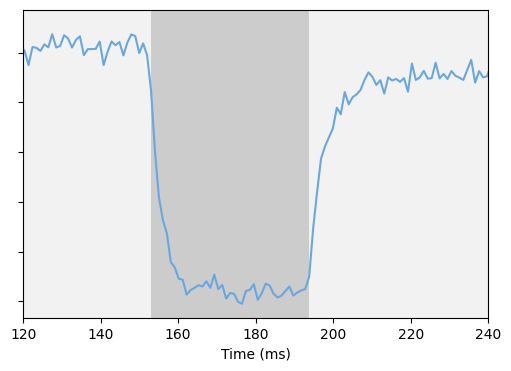

In [98]:
fig, ax = plt.subplots(figsize=(6,4)) # 6,4 

ax.plot(norm_meas1.index, norm_meas1, label="O. basilicum", color=colors[0], linestyle = "-")
# ax.plot(norm_meas2.index, norm_meas2, label="P. crispum", color=colors[1], linestyle = "-")
# ax.plot(norm_sim.index, norm_sim, label="Simulation", color=colors[2], linewidth = 2, linestyle = "-") # *10-150*10+150

shade_light(c, ax)
ax.set_yticklabels([])

# light_level_label = Line2D([], [], color='none', label=f"{AL_level} µE")
# ax.add_artist(ax.legend(handles=[light_level_label], loc="lower left", handlelength=0, handletextpad=0))

ax.set(xlim=(120, 240),
    xlabel=("Time (ms)"))

#ax.set_xlim(100,300)
# ax.legend(loc="lower right")
#ax.set_yscale("log")

In [64]:
save_fig(fig, "DIRKs" ,"sim_meas_fit_overlay",  f"simulation_two_herbs_P700_{AL_level}pfd")
#save_fig(fig, "DIRKs" ,"sim_meas_fit_overlay",  f"simulation_two_herbs_ECS_{AL_level}pfd")

existing figure backed up to figures/DIRKs/sim_meas_fit_overlay/Z_backup_simulation_two_herbs_P700_1000pfd.png
saved figure to figures/DIRKs/sim_meas_fit_overlay/simulation_two_herbs_P700_1000pfd.png
